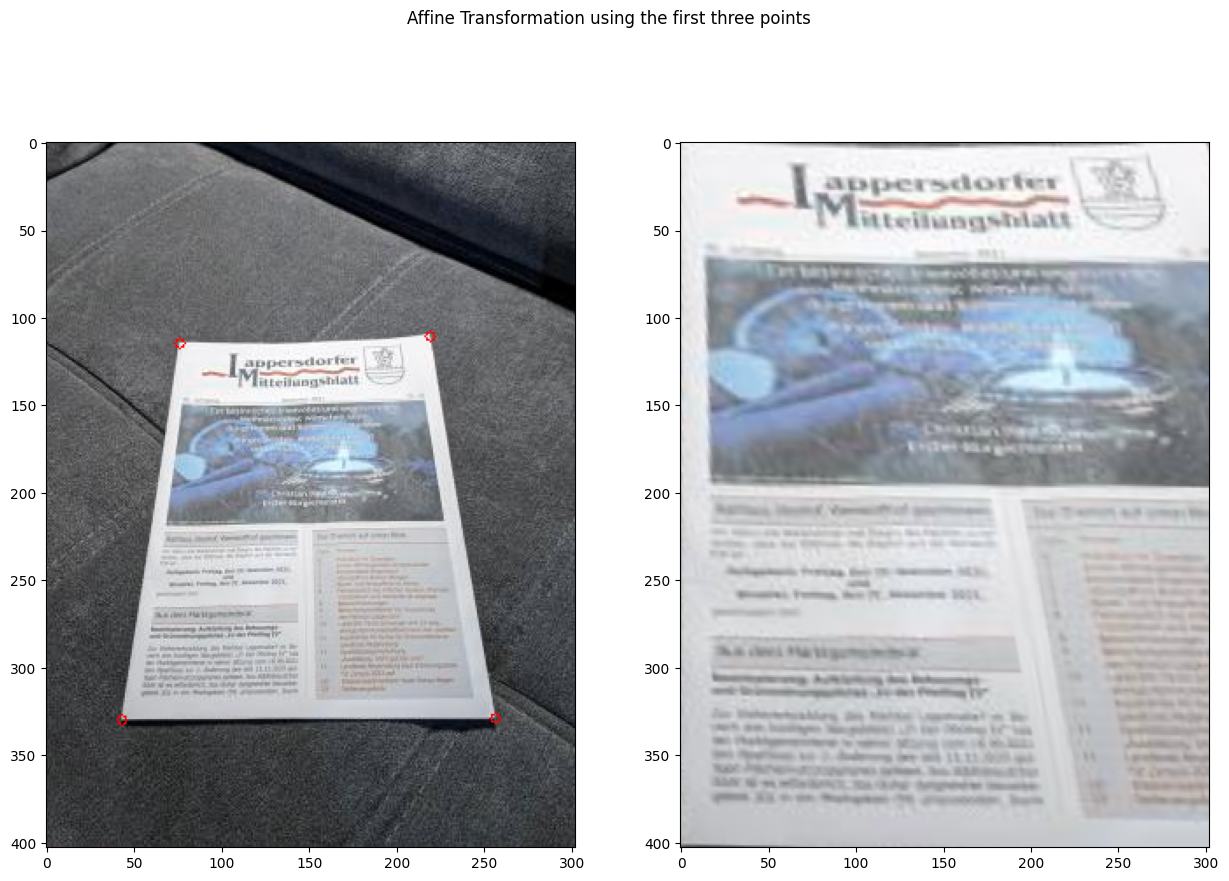

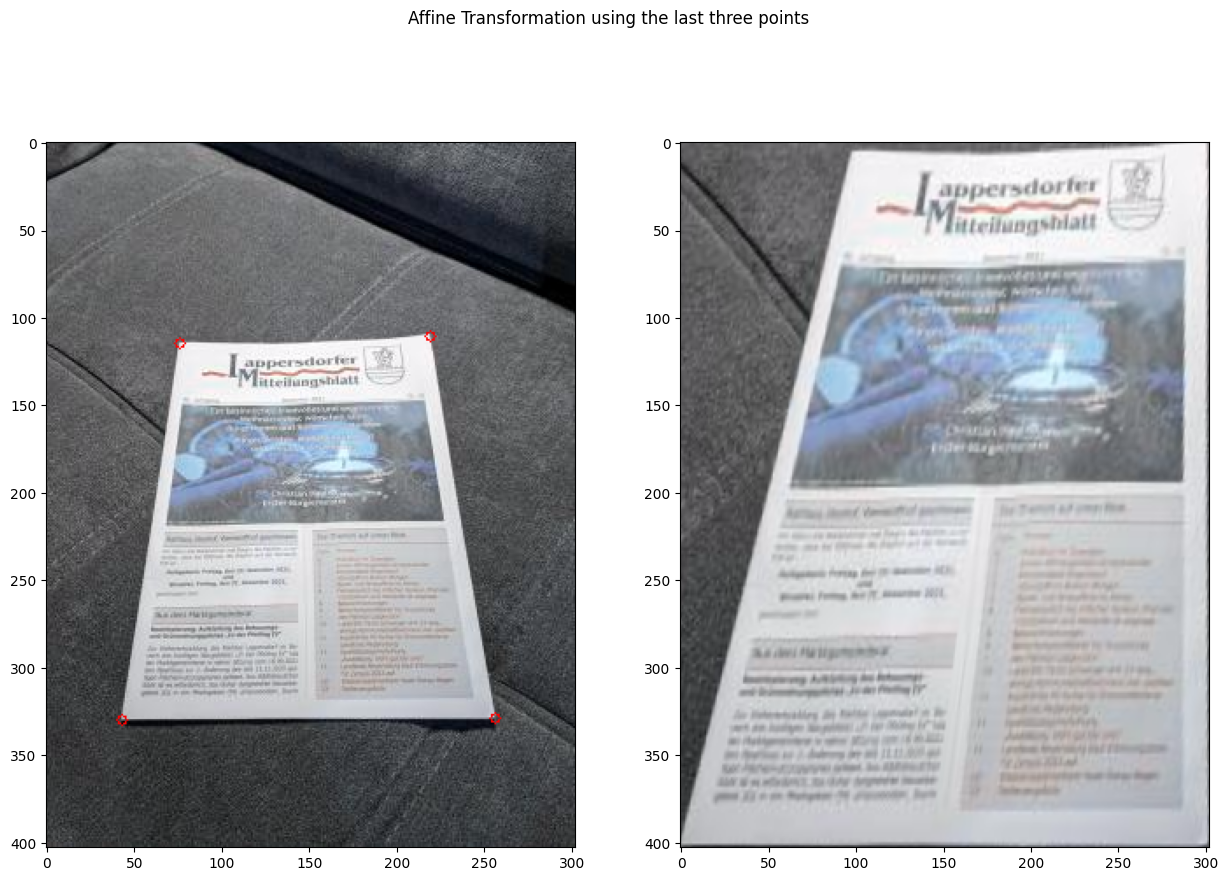

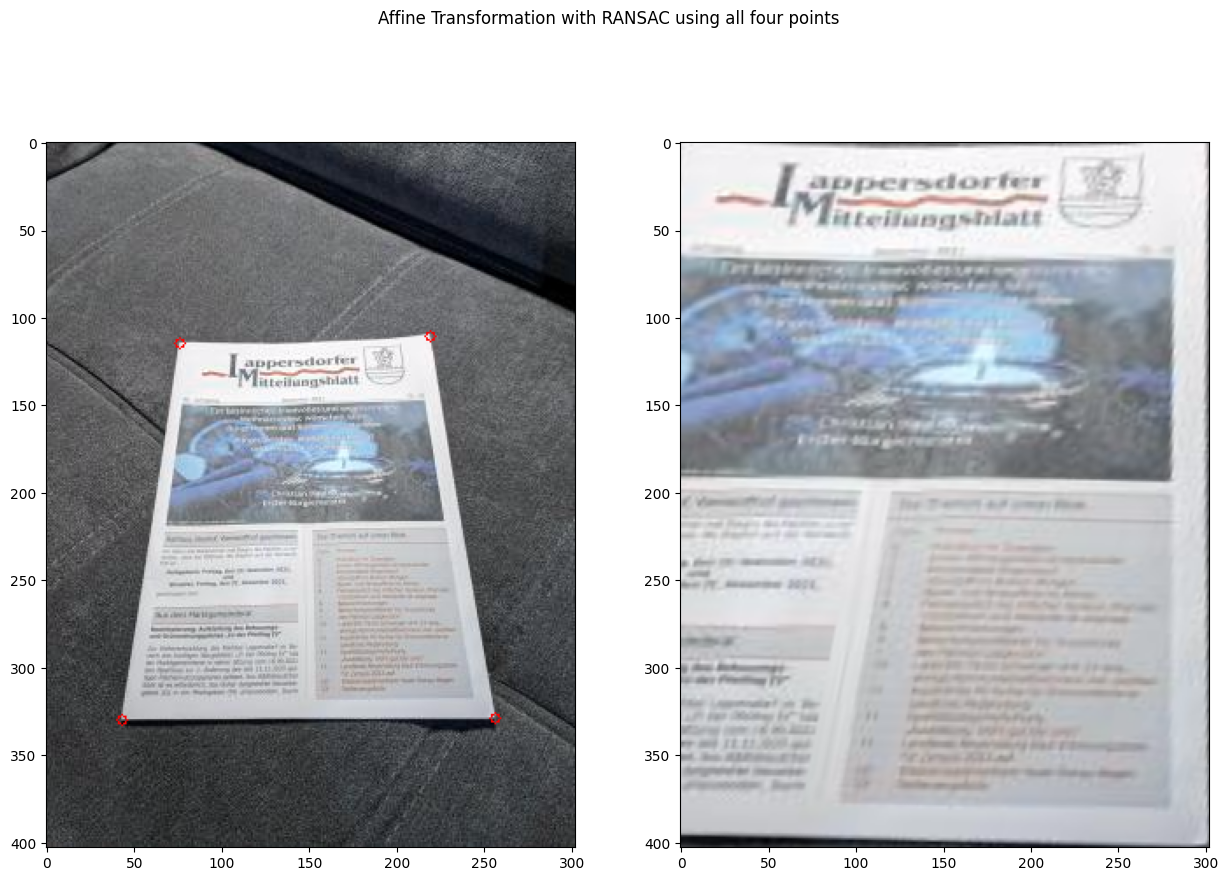

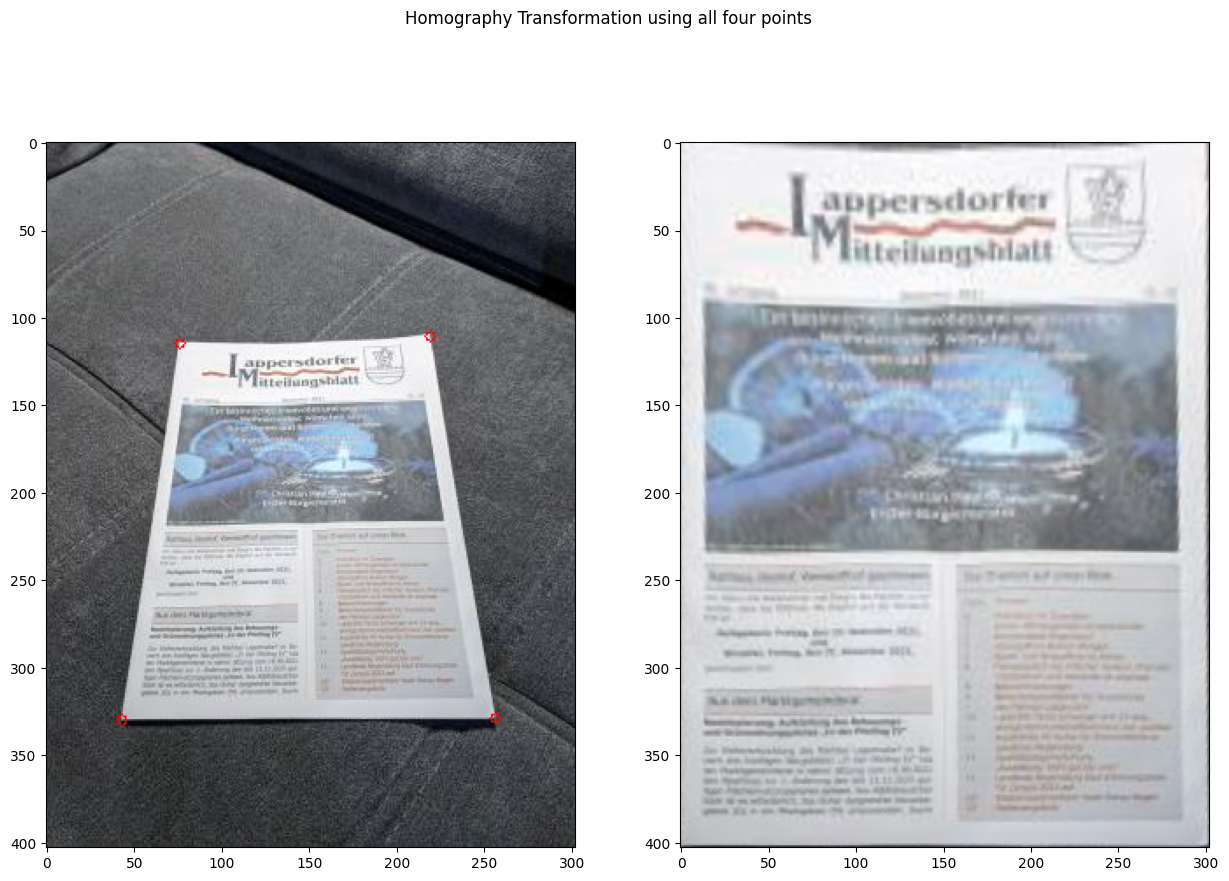

In [65]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

img = cv2.imread('../../data/lesson_6/document.jpg')

if img is None:
    print("Could not read the image.")
    exit()

gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)/255
rows, cols = gray.shape

top_left = [76, 115]
top_right = [219, 111]
bottom_left = [43, 330]
bottom_right = [256, 329]

out = np.copy(img)
out = cv2.circle(out, tuple(top_left), 3, (255,0,0), 1)
out = cv2.circle(out, tuple(top_right), 3, (255,0,0), 1)
out = cv2.circle(out, tuple(bottom_left), 3, (255,0,0), 1)
out = cv2.circle(out, tuple(bottom_right), 3, (255,0,0), 1)

src_points = np.array([top_left, top_right, bottom_left, bottom_right], dtype=np.float32)
dst_points = np.array([[0, 0], [cols-1, 0], [0, rows-1], [cols-1, rows-1]], dtype=np.float32)


# Affine transformation using the first three points
M = cv2.getAffineTransform(src_points[:3], dst_points[:3])
rectified_first_points = cv2.warpAffine(img, M, (cols, rows))

plt.subplot(121), plt.imshow(out)
plt.subplot(122), plt.imshow(rectified_first_points)
plt.suptitle('Affine Transformation using the first three points')
plt.show()


# Affine transformation using the last three points
M = cv2.getAffineTransform(src_points[-3:], dst_points[-3:])
rectified_last_points = cv2.warpAffine(img, M, (cols, rows))

plt.subplot(121), plt.imshow(out)
plt.subplot(122), plt.imshow(rectified_last_points)
plt.suptitle('Affine Transformation using the last three points')
plt.show()


# Affine transformation winth RANSAC using all four points
M, inliners = cv2.estimateAffine2D(src_points, dst_points, method=cv2.RANSAC)
rectified_ransac = cv2.warpAffine(img, M, (cols, rows))

plt.subplot(121), plt.imshow(out)
plt.subplot(122), plt.imshow(rectified_ransac)
plt.suptitle('Affine Transformation with RANSAC using all four points')
plt.show()


# Homography transformation using all four points
src = np.array(src_points, dtype=np.float32)
dst = np.array(dst_points, dtype=np.float32)

M_homography = cv2.getPerspectiveTransform(src, dst)
rectified_homography = cv2.warpPerspective(img, M_homography, (cols, rows))

plt.subplot(121), plt.imshow(out)
plt.subplot(122), plt.imshow(rectified_homography)
plt.suptitle('Homography Transformation using all four points')
plt.show()


The affine transform does not seem to be working well in this case. Why?
> Путем эксперимента который был большей частью домашнего задания на практике смог понять что такое степени свободы аффинной трансформации и что их не хватает для сцен, где есть перспектива. Как не меняй входные три точки их не будет достаточно что бы правильно применить трансформацию, так как для нашей задачи необходимо учесть перспективу, то гомография справилась отлично так как у нее 8 степеней свободы и 4 точки на входе.

What can you tell me about the values you have obtained for the inliers vector? What does it mean?
> Возвращает двухмерный массив размером в нашем случае 4х1, который содержит либо 1 либо 0, то есть как маска соответствия, 1 - значит RANSAC определил ее как подходящую, 0 - значит точка была исключена. У нас вышло [[1], [1], [0], [1]]
То есть еще олин вариант из трех точек(не первые три и не последние три) но как видно на практике результат от этого не улучшился, хоть и выглядит немного по другому(ожидаемо :) )

How does the result from homography look? Does it work well enough?
> Как по мне, гомография справилась на отлично. Изменила перспективу, разместила углы документа по углам нового изображения да и в целом выглядит как магия, всегда удивлялся как приложение Заметки на iPhone умеют так сканировать документы изменяя перспективу, теперь знаю :)
Обязательно попробую з более четкими изображением и сложной перспективой, что бы оценить как себя ведет текст, но думаю результат будет отличный!